# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

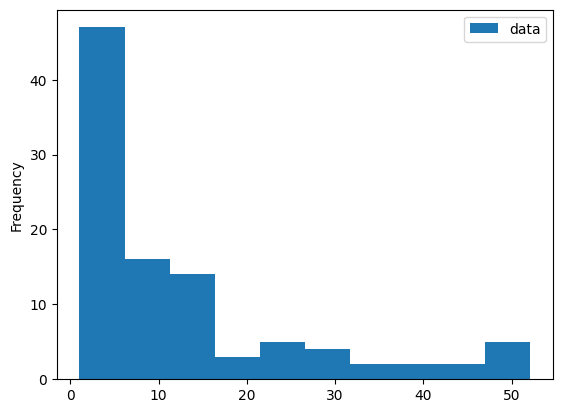

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

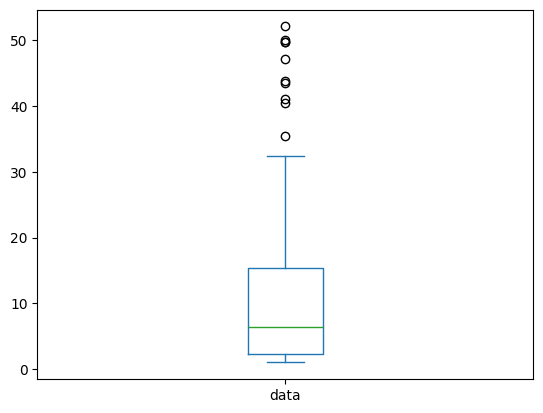

In [3]:
df.plot.box()

The strengths of the histogram is how quickly and effectively it conveys the skew of the data and how simple it is to read the count of each bin. The strengths of the box plot is highlighting outliers and showing basic statistics like the average and percentile marks.

I think the box plot is clearer for the purpose of setting benchmarks for the prices of drugs because the statistics and outlier highlighting are likely most useful for comparing drug prices to other prices.

The main change to the plot needed is basic labeling. It lacks a title. Explicitly labeling key statistics such as the mean would also be helpful for those just skimming the information.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
import matplotlib.pyplot as plt

In [5]:
#Import first dataset, 2015 Flight Delay Data
#Columns 7,8 needed dtype specified directly as infer failed
#Copying over the same preparation steps from HW2

flights_2015 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2015_Delay_Data\flights.csv", dtype={"DESTINATION_AIRPORT":str, "ORIGIN_AIRPORT":str})

flights_2015.fillna({"AIR_SYSTEM_DELAY":0,"SECURITY_DELAY":0,"AIRLINE_DELAY":0,"LATE_AIRCRAFT_DELAY":0,"WEATHER_DELAY":0}, inplace=True)
flights_2015.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0


In [6]:
flights_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

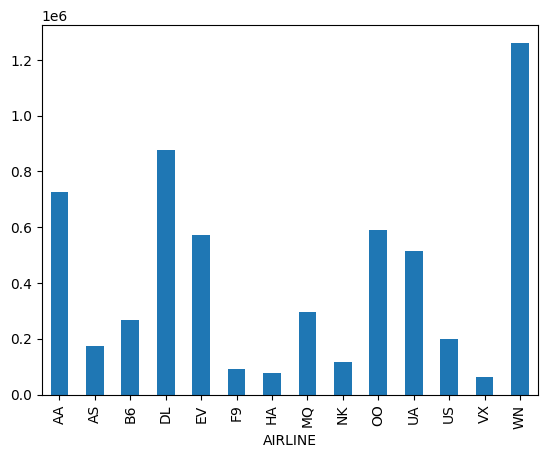

In [7]:
flights_2015.value_counts("AIRLINE", ascending=True, sort=False).plot.bar("AIRLINE");

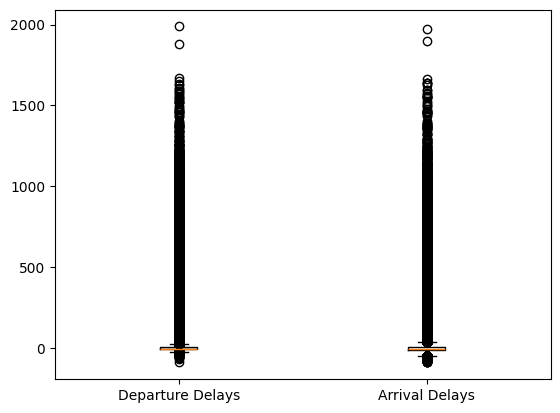

In [8]:
plt.boxplot([flights_2015["DEPARTURE_DELAY"].dropna(), flights_2015["ARRIVAL_DELAY"].dropna()], tick_labels=["Departure Delays", "Arrival Delays"])
plt.show()

I spent a lot of time playing around with how to represent this data, but ultimately there is no clear way to demonstrate all of the data that is not comical. Essentially all of the data is within a very small margin of no delay, but the outliers can be very extreme. It is good to realize this since simply labeling a flight as "delayed" is not going to be very constructive if it lumps in a 5 minute delay with a multi-hour delay. Slightly delayed flights should be acceptable and represent the strong majority of all domestic flights. 

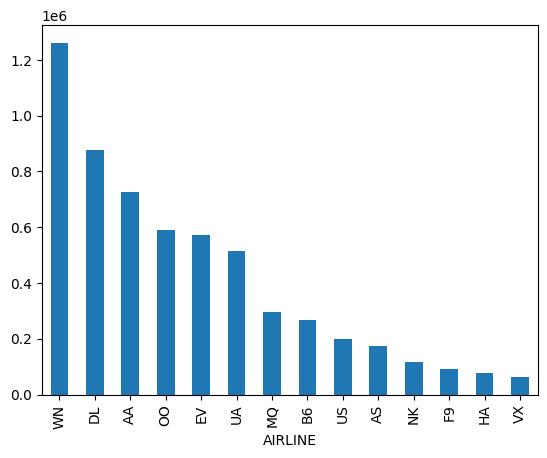

In [9]:
flights_2015["AIRLINE"].value_counts().plot.bar();

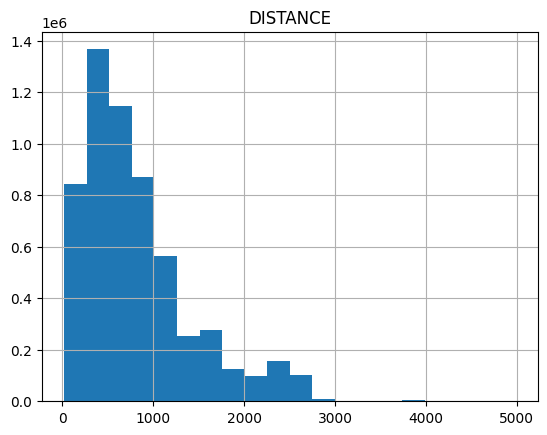

In [10]:
flights_2015.hist("DISTANCE", bins=20);

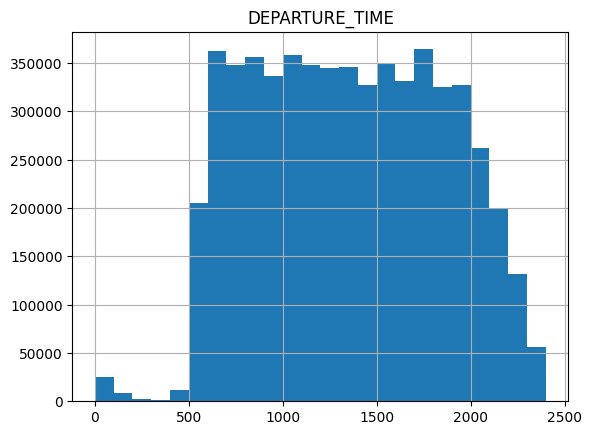

In [11]:
flights_2015.hist("DEPARTURE_TIME", bins=24);

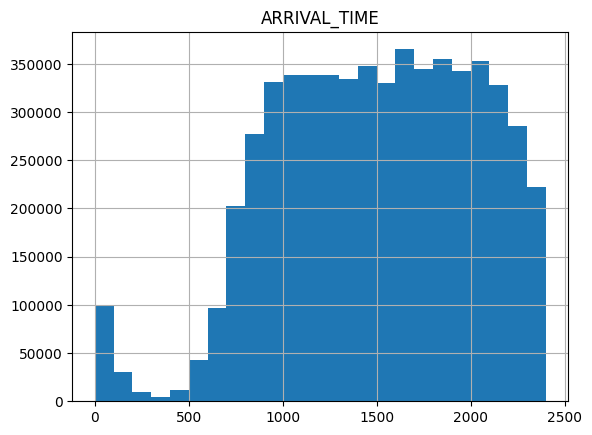

In [12]:
flights_2015.hist("ARRIVAL_TIME", bins=24);

Unsurprisingly, the arrival times look like the shape of the departure times, just shifted a bit later.

A lot of the columns in this dataset simply do not make sense to graph as there as so many values, such as 628 origin airports, that any plot trying to show them all will inevitably just end up over crowded and unhelpful.

In [13]:
#Import 2nd Dataset, 2019 Flight Delay Info

delays_2019 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2019_Delay_Data\full_data_flightdelay.csv")

delays_2019.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,8,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,3,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,18,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,2,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,1,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91


In [14]:
delays_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6489062 entries, 0 to 6489061
Data columns (total 26 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   MONTH                          int64  
 1   DAY_OF_WEEK                    int64  
 2   DEP_DEL15                      int64  
 3   DEP_TIME_BLK                   object 
 4   DISTANCE_GROUP                 int64  
 5   SEGMENT_NUMBER                 int64  
 6   CONCURRENT_FLIGHTS             int64  
 7   NUMBER_OF_SEATS                int64  
 8   CARRIER_NAME                   object 
 9   AIRPORT_FLIGHTS_MONTH          int64  
 10  AIRLINE_FLIGHTS_MONTH          int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  int64  
 12  AVG_MONTHLY_PASS_AIRPORT       int64  
 13  AVG_MONTHLY_PASS_AIRLINE       int64  
 14  FLT_ATTENDANTS_PER_PASS        float64
 15  GROUND_SERV_PER_PASS           float64
 16  PLANE_AGE                      int64  
 17  DEPARTING_AIRPORT              object 
 18  LA

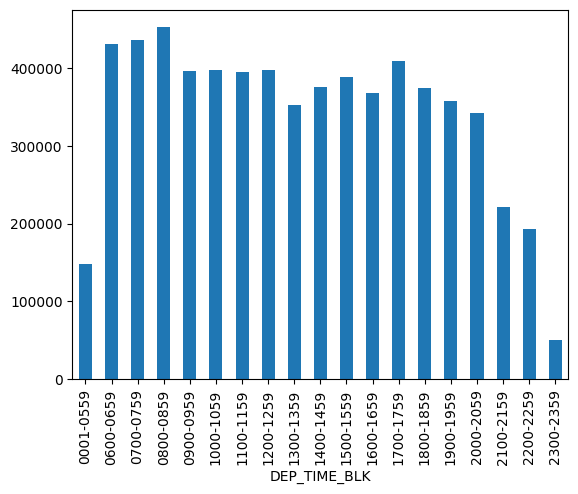

In [15]:
delays_2019.value_counts("DEP_TIME_BLK", ascending=True, sort=False).plot.bar("DEP_TIME_BLK");

There is not a departure block for every hour. It makes sense with how few flights depart after midnight and before 6 AM.

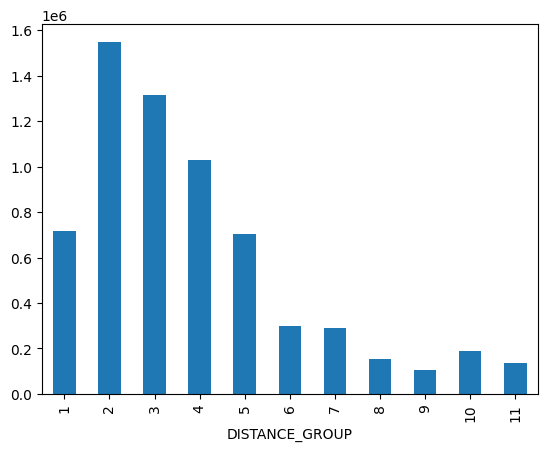

In [16]:
delays_2019.value_counts("DISTANCE_GROUP", ascending=True, sort=False).plot.bar("DISTANCE_GROUP");

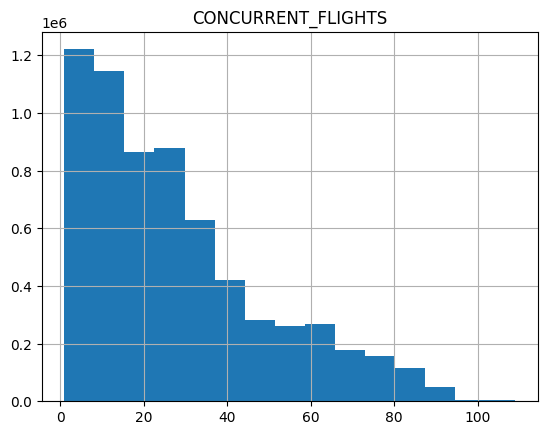

In [17]:
delays_2019.hist("CONCURRENT_FLIGHTS", bins=15);

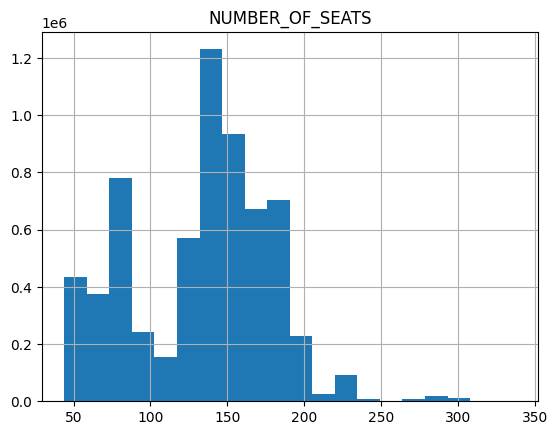

In [18]:
delays_2019.hist("NUMBER_OF_SEATS", bins = 20);

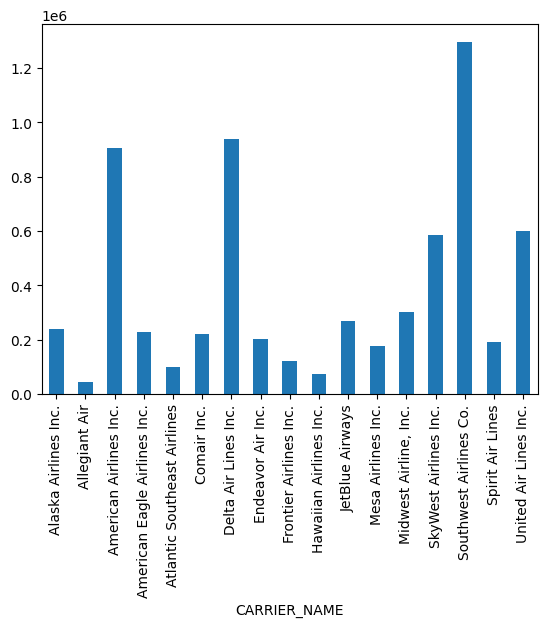

In [19]:
delays_2019.value_counts("CARRIER_NAME", ascending=True, sort=False).plot.bar("CARRIER_NAME");

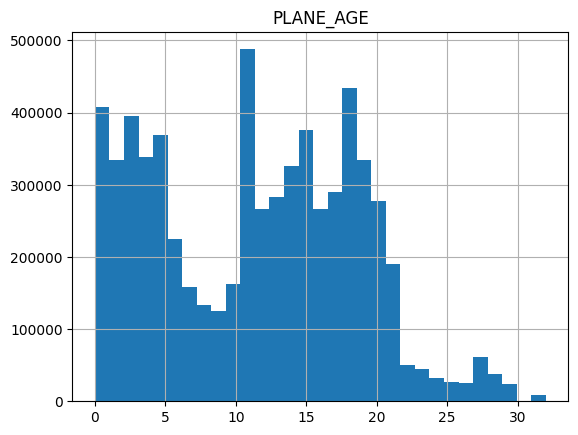

In [20]:
delays_2019.hist("PLANE_AGE", bins=31);

There is a huge dip in the number of planes that were made in 2008 to 2013. I suspect that is related to the 2008 financial crash, because travel was hit especially hard.

Also, it seems retiring planes after about 20 years is a standard practice.

In [21]:
#Import 3rd Dataset
#Prep work from HW2

delay_causes = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\Flight_Delay_and_Causes_Data\Flight_delay.csv")

delay_causes.drop_duplicates(keep="first", inplace=True)
                           
delay_causes.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


In [22]:
delay_causes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 484549 entries, 0 to 484550
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DayOfWeek          484549 non-null  int64 
 1   Date               484549 non-null  object
 2   DepTime            484549 non-null  int64 
 3   ArrTime            484549 non-null  int64 
 4   CRSArrTime         484549 non-null  int64 
 5   UniqueCarrier      484549 non-null  object
 6   Airline            484549 non-null  object
 7   FlightNum          484549 non-null  int64 
 8   TailNum            484549 non-null  object
 9   ActualElapsedTime  484549 non-null  int64 
 10  CRSElapsedTime     484549 non-null  int64 
 11  AirTime            484549 non-null  int64 
 12  ArrDelay           484549 non-null  int64 
 13  DepDelay           484549 non-null  int64 
 14  Origin             484549 non-null  object
 15  Org_Airport        483372 non-null  object
 16  Dest               484549

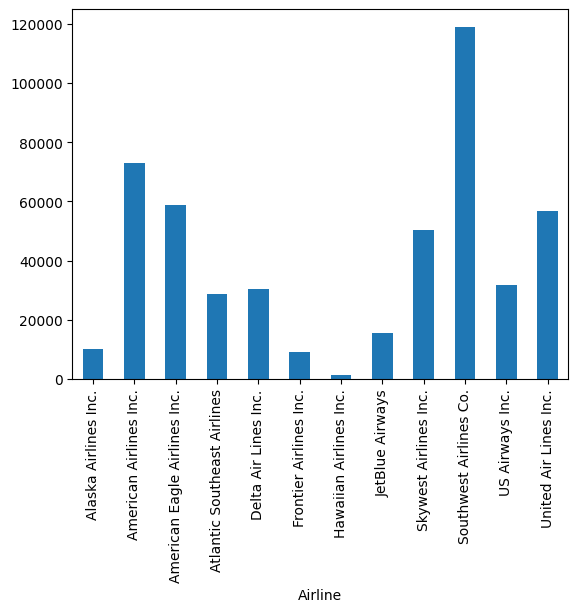

In [23]:
delay_causes.value_counts("Airline", ascending=True, sort=False).plot.bar("Airline");

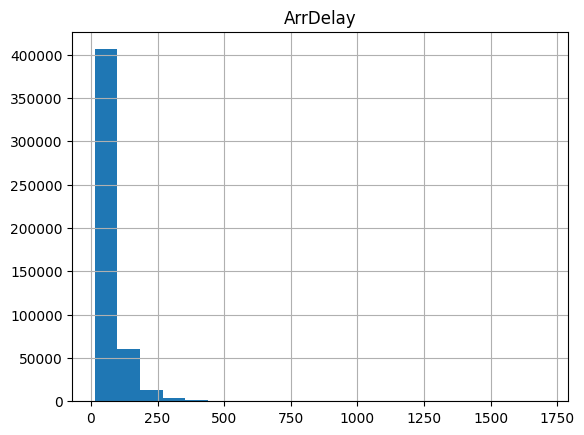

In [24]:
delay_causes.hist("ArrDelay", bins = 20);

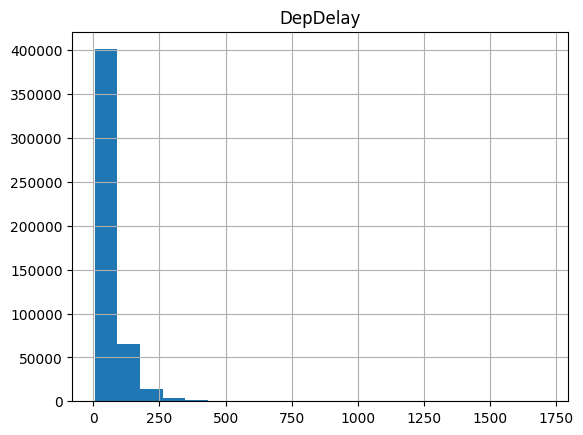

In [25]:
delay_causes.hist("DepDelay", bins = 20);

Once again, the vast majority of flights are either not delayed or are minorly delayed

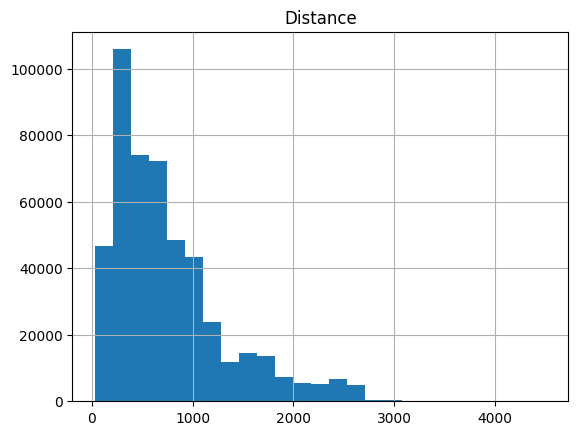

In [26]:
delay_causes.hist("Distance", bins=25);

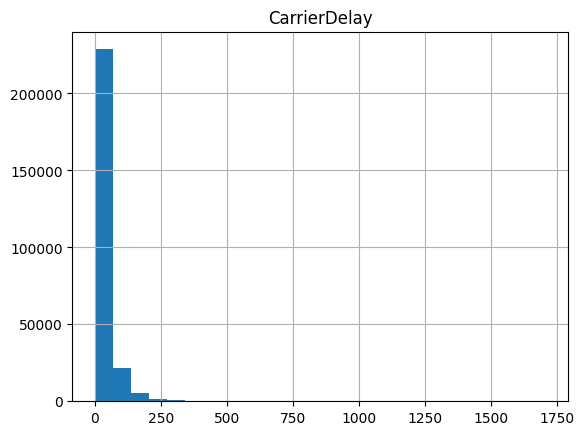

In [27]:
nulls = delay_causes[delay_causes["CarrierDelay"]==0].index

delay_causes.drop(nulls).hist("CarrierDelay", bins=25);

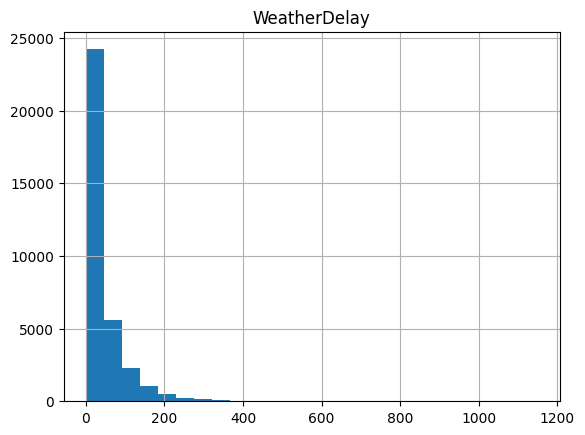

In [28]:
nulls = delay_causes[delay_causes["WeatherDelay"]==0].index

delay_causes.drop(nulls).hist("WeatherDelay", bins=25);

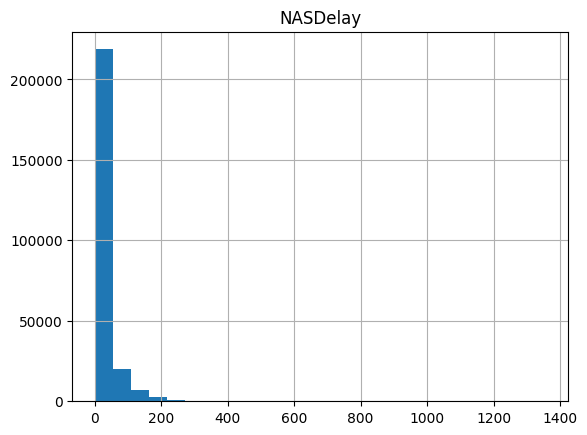

In [29]:
nulls = delay_causes[delay_causes["NASDelay"]==0].index

delay_causes.drop(nulls).hist("NASDelay", bins=25);

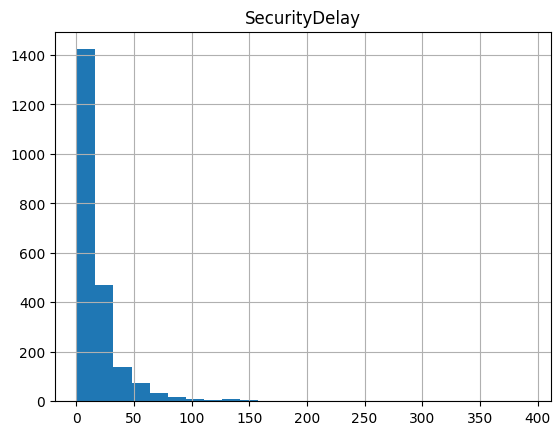

In [30]:
nulls = delay_causes[delay_causes["SecurityDelay"]==0].index

delay_causes.drop(nulls).hist("SecurityDelay", bins=25);

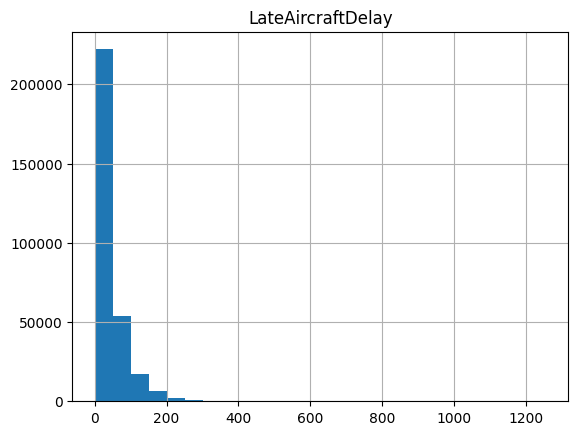

In [31]:
nulls = delay_causes[delay_causes["LateAircraftDelay"]==0].index

delay_causes.drop(nulls).hist("LateAircraftDelay", bins=25);

Unsurprisingly, most flights are not delayed for any specific reason. I removed the flights with no delays in each category to better show the shape of the rest of the plot.

In [32]:
domestic_data_2024 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\T100_Domestic_Market_and_Segment_Data_8942359590531559889.csv")

domestic_data_2024.head()

,OBJECTID,year,origin,enplanements,passengers,departures,arrivals,freight,mail
0,1,2024,01A,17,17,5,5,0,0
1,2,2024,05A,1,1,1,1,0,0
2,3,2024,06A,50,55,67,66,139,0
3,4,2024,09A,41,43,15,15,0,0
4,5,2024,1B1,32,32,7,7,0,0


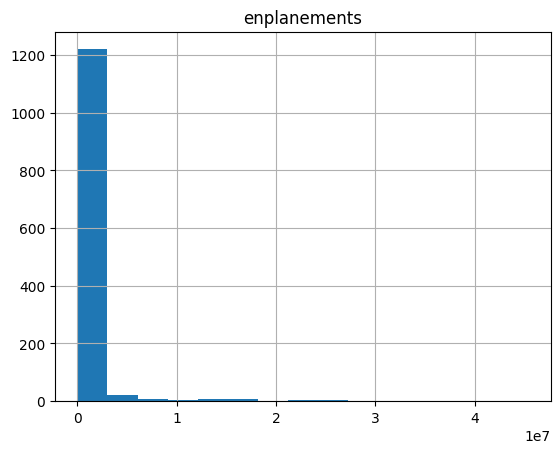

In [33]:
domestic_data_2024.hist("enplanements", bins=15);

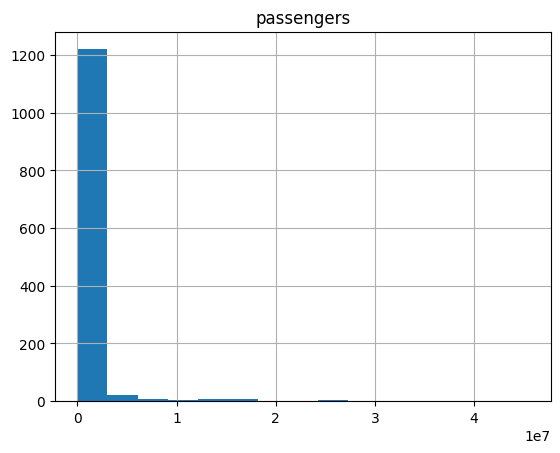

In [35]:
domestic_data_2024.hist("passengers", bins=15);

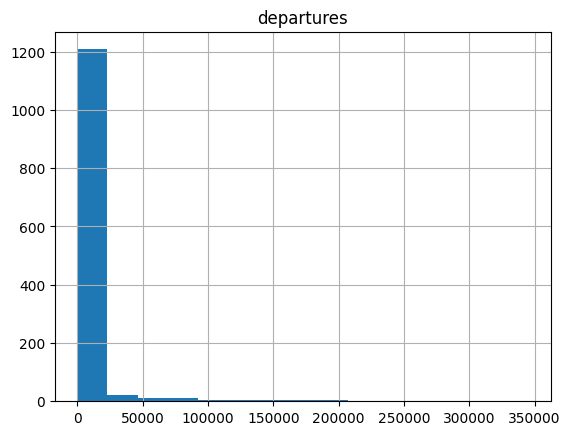

In [36]:
domestic_data_2024.hist("departures", bins=15);

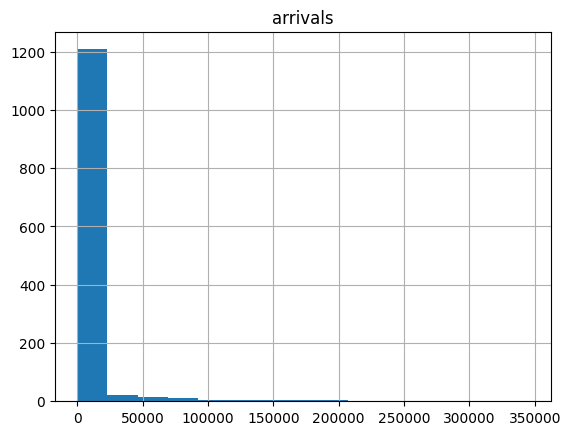

In [37]:
domestic_data_2024.hist("arrivals", bins=15);

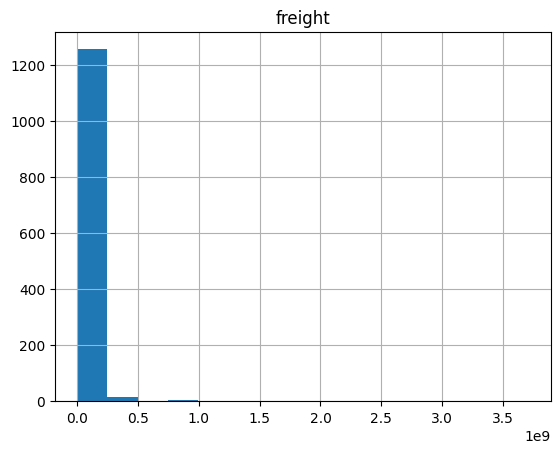

In [38]:
domestic_data_2024.hist("freight", bins=15);

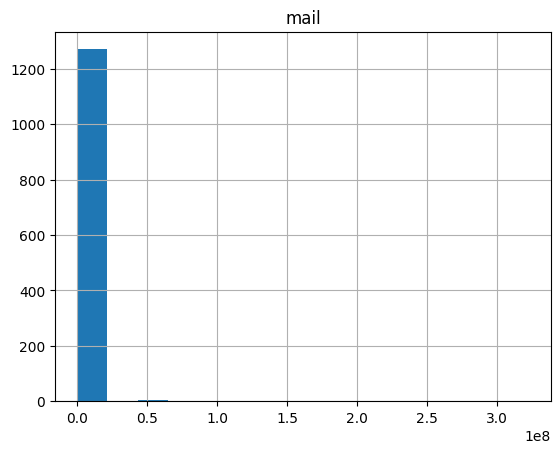

In [39]:
domestic_data_2024.hist("mail", bins=15);

Most airports are tiny, obscure and barely used.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

<Figure size 600x800 with 0 Axes>

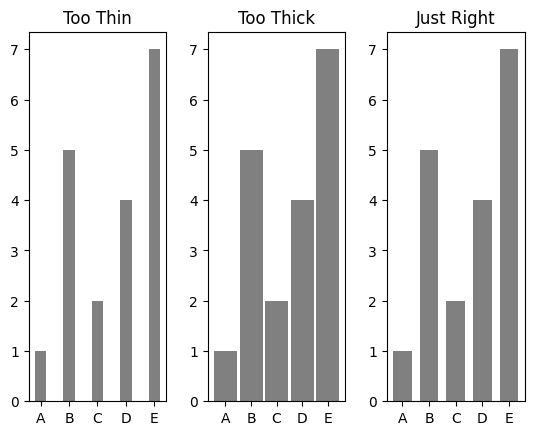

In [34]:
labels = ["A","B","C","D","E"]
data = [1,5,2,4,7]

plt.figure(figsize=(6,8))

plt.subplots(1,3)

plt.subplots_adjust(hspace=.3, wspace=.3)

plt.subplot(1,3,1)
plt.bar(labels, data, color="grey", width=.4)
plt.title("Too Thin")

plt.subplot(1,3,2)
plt.bar(labels, data, color="grey", width=.9)
plt.title("Too Thick")

plt.subplot(1,3,3)
plt.bar(labels, data, color="grey", width=.7)
plt.title("Just Right")

plt.show()